In [1]:
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
import sys

project_root = 'C:/Code/Github/GLM-analysis/'
if project_root not in sys.path:
    sys.path.append(project_root)

from handlers.DataHandlerEncoding import DataHandlerEncoding as datafun
from analysis.AnalysisManagerEncoding import AnalysisManagerEncoding as analysisfun
from utils.Plotter import Plotter as plotterfun
from utils.general_stats import GeneralStats



In [2]:
data_handler = datafun(data=None)  # Pass any initial data if needed

info_dir = 'V:/Connie/results/opto_2024/context/mod'
datasets, mouse_dates_keys = data_handler.load_info(info_dir)

#remove datasets for now while some are still running - finished: 0,1,2,3,4,5,6,7,11,14
# Indices to remove (example: remove datasets at indices 0 and 2)
remove_indices = list(set(range(0,25)) - set([0,1,2,3,4,5,6,7,11,14])) #[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24] #[2,3,8,18]

# Remove indices from both lists
datasets = [dat for i, dat in enumerate(datasets) if i not in remove_indices]
mouse_dates_keys = [key for i, key in enumerate(mouse_dates_keys) if i not in remove_indices]


model_type = 'GLM_3nmf_pre'
results_pre = data_handler.process_multiple_datasets(datasets, model_type, results_type='results_updated',models_to_load=[5]) #1-4 to load 10
# model_type = 'GLM_3nmf_passive'
# results_pass = data_handler.process_multiple_datasets(datasets, model_type, results_type='results_updated',models_to_load=[5])

dir = os.path.join('W:\Connie/results\Bassi2025\data')
#load significant sound/opto neurons
opto, sound, mouse_dates, significant_neurons, mod_indices = data_handler.load_sound_opto_data(dir, set_diff = True, exclude = "HE1-00_2023-05-30")

Processing dataset: HA11-1R_2023-05-05
poss_model_5_data_cluster_0.pkl
poss_model_5_data_cluster_1.pkl
poss_model_5_data_cluster_2.pkl
poss_model_5_data_cluster_3.pkl
poss_model_5_data_cluster_4.pkl
poss_model_5_data_cluster_5.pkl
poss_model_5_data_cluster_6.pkl
poss_model_5_data_cluster_7.pkl
poss_model_5_data_cluster_8.pkl
poss_model_5_data_cluster_9.pkl
poss_model_5_data_cluster_10.pkl
poss_model_5_data_cluster_11.pkl
poss_model_5_data_cluster_12.pkl
poss_model_5_data_cluster_13.pkl
poss_model_5_data_cluster_14.pkl
poss_model_5_data_cluster_15.pkl
poss_model_5_data_cluster_16.pkl
poss_model_5_data_cluster_17.pkl
poss_model_5_data_cluster_18.pkl
poss_model_5_data_cluster_19.pkl
poss_model_5_data_cluster_20.pkl
poss_model_5_data_cluster_21.pkl
poss_model_5_data_cluster_22.pkl
poss_model_5_data_cluster_23.pkl
poss_model_5_data_cluster_24.pkl
poss_model_5_data_cluster_25.pkl
poss_model_5_data_cluster_26.pkl
poss_model_5_data_cluster_27.pkl
poss_model_5_data_cluster_28.pkl
poss_model_5_d

In [3]:
del results_pre['HA2-1L_2023-04-28']

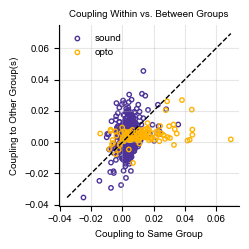

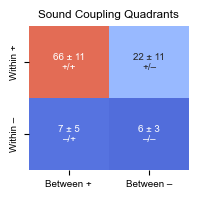

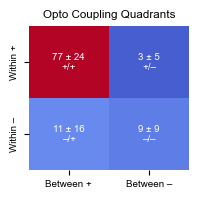

Chi-square test between sound and opto:
  χ² = 25.60, p = 1.156e-05, dof = 3
  Contingency Table:
       +/+  +/–  –/+  –/–
sound  466  178   38   35
opto    88    4   10    7
Permutation test p-value: 0.044, observed stat: 0.373
sound: p=0.0196, stat=0.001
opto: p=0.0002, stat=0.009
Bonferroni corrected alpha threshold: 0.02500
Saving stats to W:\Connie/results\Bassi2025\glm_coupling/all_neuron_coupling


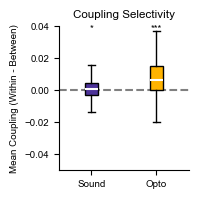

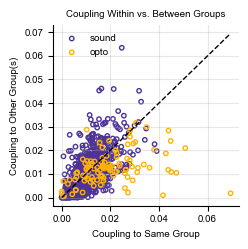

sound: p=0.2646, stat=0.000
opto: p=0.0002, stat=0.007
Bonferroni corrected alpha threshold: 0.02500
Saving stats to W:\Connie/results\Bassi2025\glm_coupling/all_neuron_coupling


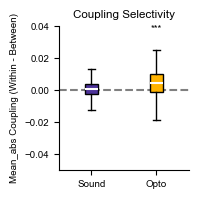

In [ ]:
save_results = f'W:\Connie/results\Bassi2025\glm_coupling/all_neuron_coupling' #f'V:/Connie/results/glm/2025/updated'
os.makedirs(save_results, exist_ok=True)

#initialize classes
plotter = plotterfun(data = None, save_results= save_results)
stats = GeneralStats()  # instantiate it
analysis_manager = analysisfun(data = None, plotter=plotter)

all_results = results_pre
mode = 'mean'  #'mean' 'median'

coupling_df = analysis_manager.wrapper_dataset_compute_within_between_coupling(all_results,significant_neurons, mode = mode, groups_to_plot = ['sound','opto'])

plotter.plot_within_between_scatter(
    coupling_df,
    group_colors=plotter.group_colors,
    title='Coupling Within vs. Between Groups',
    figsize=(2.5, 2.5),
    save_path=None, #'pooled_opto_vs_sound_coupling.pdf'
    mode = mode
)

quad_stats = plotter.plot_quadrant_heatmap_across_datasets(
    combined_df=coupling_df,
    groups=['sound', 'opto'],
    save_dir=None,#'W:/Connie/results/Bassi2025/glm_coupling/heatmaps'
    figsize=(2,2),
    decimal_places=0,
    vmax = 77
)

p_value, observed_stat, permuted_stats = stats.permutation_test_quadrants(quad_stats['sound']['raw_counts'], quad_stats['opto']['raw_counts'], n_permutations=1000, seed=42) #stats['sound']['mean'].reshape(2,2)
print(f"Permutation test p-value: {p_value:.4g}, observed stat: {observed_stat:.3f}")

summary = plotter.plot_group_coupling_differences(coupling_df, mode= mode, paired=True, ylim =(-.05,0.04), figure_size=(2,2),
                                        group_order = ['Sound','Opto'],group_colors= plotter.group_colors, plot_type='box',width = 0.2, showfliers=False,
                                        save_path = 'W:\Connie/results\Bassi2025\glm_coupling/all_neuron_coupling/coupling_selectivity_boxplot.pdf')


# now look at absolute value of coupling betas
mode = 'mean_abs'  #'mean' 'median'

coupling_df = analysis_manager.wrapper_dataset_compute_within_between_coupling(all_results,significant_neurons, mode = mode, groups_to_plot = ['sound','opto'])

plotter.plot_within_between_scatter(
    coupling_df,
    group_colors=plotter.group_colors,
    title='Coupling Within vs. Between Groups',
    figsize=(2.5, 2.5),
    save_path=None, #'pooled_opto_vs_sound_coupling.pdf'
    mode = mode
)


summary = plotter.plot_group_coupling_differences(coupling_df, mode= mode, paired=True, ylim =(-.05,0.04), figure_size=(2,2),
                                        group_order = ['Sound','Opto'],group_colors= plotter.group_colors, plot_type='box',width = 0.2, showfliers=False,
                                        save_path = f'W:\Connie/results\Bassi2025\glm_coupling/all_neuron_coupling/coupling_selectivity_boxplot_{mode}.pdf')

sound: p=0.0184, stat=0.001
opto: p=0.0002, stat=0.009
Bonferroni corrected alpha threshold: 0.02500
Saving stats to W:\Connie/results\Bassi2025\glm_coupling/all_neuron_coupling


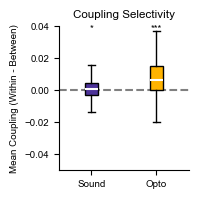

In [167]:
# def plot_group_coupling_differences(df, mode='mean_abs', save_path=None, paired=True,
#                                     figure_size=(3,3), ylim=None, group_colors=None,
#                                     plot_type='bar'):
#     import seaborn as sns
#     import matplotlib.pyplot as plt
#     import numpy as np
#     import matplotlib as mpl

#     mpl.rcParams['pdf.fonttype'] = 42
#     plt.rcParams.update({'font.size': 7, 'font.family': 'arial'})

#     df['diff'] = df['coupling_within'] - df['coupling_between']
#     summary = df.groupby('group')['diff'].agg(['mean', 'sem'])

#     groups = summary.index.tolist()

#     # Use user-provided colors or fallback
#     if group_colors is None:
#         palette = dict(zip(groups, sns.color_palette('muted', n_colors=len(groups))))
#     else:
#         palette = group_colors

#     fig, ax = plt.subplots(figsize=figure_size)
#     ax.axhline(0, linestyle='--', color='gray')
#     if plot_type == 'bar':
#         # Barplot from summary stats
#         means = summary['mean'].values
#         sems = summary['sem'].values
#         bar_colors = [palette[g] for g in groups]
#         ax.bar(groups, means, color=bar_colors, edgecolor='black', linewidth=0.5)
#         for i, (m, s) in enumerate(zip(means, sems)):
#             ax.errorbar(i, m, yerr=s, fmt='none', ecolor='black', capsize=2)

#     elif plot_type == 'box':
#         sns.boxplot(data=df, x='group', y='diff', palette=palette, ax=ax,
#                     width=0.6, linewidth=0.7, fliersize=2)

#     else:
#         raise ValueError(f"Unsupported plot_type: {plot_type}. Use 'bar' or 'box'.")

    
#     ax.set_ylabel(f'{mode.capitalize()} Coupling (Within - Between)')
#     ax.set_title('Coupling Selectivity')
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)
#     if ylim:
#         ax.set_ylim(ylim)

#     plt.tight_layout()
#     if save_path:
#         plt.savefig(save_path, dpi=300)

#     # Paired permutation test (against zero)
#     pvals = []
#     for g in groups:
#         vals = df[df['group'] == g]['diff'].dropna().values
#         p, stat = stats.perform_permutation_test(vals, np.zeros_like(vals), paired=paired)
#         print(f"{g}: p={p:.4f}, stat={stat:.3f}")
#         pvals.append(p)

#     return summary

def plot_group_coupling_differences(
    df, 
    mode='mean_abs', 
    save_path=None, 
    paired=True, 
    figure_size=(3, 3), 
    ylim=None, 
    group_colors=None,
    group_order=None,
    plot_type='bar',  # 'bar' or 'box'
    width = 0.6,
    showfliers=True
):
    import seaborn as sns
    import matplotlib.pyplot as plt
    import matplotlib as mpl
    from matplotlib.patches import Patch

    mpl.rcParams['pdf.fonttype'] = 42
    plt.rcParams.update({'font.size': 7, 'font.family': 'arial'})

    df['diff'] = df['coupling_within'] - df['coupling_between']

    # Determine group order
    if group_order is None:
        group_order = sorted(df['group'].unique())
    else:
        group_names =  group_order
        group_order = [s.lower() for s in group_order] # ensure list for indexing
        

    # Grouped summary
    summary = df.groupby('group')['diff'].agg(['mean', 'sem']).reindex(group_order)

    # Set up group colors
    if group_colors is None:
        palette = sns.color_palette('muted', n_colors=len(group_order))
        group_colors = dict(zip(group_order, palette))
    
    fig, ax = plt.subplots(figsize=figure_size)
    ax.axhline(0, linestyle='--', color='gray')
    if plot_type == 'bar':
        for i, group in enumerate(group_order):
            mean_val = summary.loc[group, 'mean']
            sem_val = summary.loc[group, 'sem']
            color = group_colors.get(group, 'gray')
            ax.bar(i, mean_val, color=color, width=width)
            ax.errorbar(i, mean_val, yerr=sem_val, fmt='none', ecolor='black', capsize=2)
        ax.set_xticks(range(len(group_order)))
        ax.set_xticklabels(group_names)

    elif plot_type == 'box':
        # Draw manually for color control
        for i, group in enumerate(group_order):
            data = df[df['group'] == group]['diff'].dropna().values
            bp = ax.boxplot(data, positions=[i], widths=width, patch_artist=True,showfliers=showfliers,flierprops=dict(marker='o', markersize=2, markerfacecolor='white', markeredgecolor='gray'),
                             boxprops=dict(facecolor=group_colors.get(group, 'gray')))
            for patch in bp['boxes']:
                patch.set_facecolor(group_colors.get(group, 'gray'))
            for element in ['medians']: #medians
                for line in bp[element]:
                    line.set_color('white')
                    line.set_linewidth(1.5)
            for element in ['whiskers', 'caps']:
                for line in bp[element]:
                    line.set_color('black')
                    line.set_linewidth(1)
            
        ax.set_xticks(range(len(group_order)))
        ax.set_xticklabels(group_names)

    ax.set_ylabel(f'{mode.capitalize()} Coupling (Within - Between)')
    ax.set_title(f'Coupling Selectivity')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if ylim:
        ax.set_ylim(ylim)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)

    all_p_values = []
    all_stats_dict = {}
    test_stats = []
    comparisons_names = []
    # Paired permutation test
    for g in group_order:
        vals = df[df['group'] == g]['diff'].dropna().values
        p, stat = stats.perform_permutation_test(vals, np.zeros_like(vals), paired=paired)
        all_p_values.append(p)
        test_stats.append(stat)
        print(f"{g}: p={p:.4f}, stat={stat:.3f}")

        label1 = f"{g}_coupling_diff_stats"
        all_stats_dict[label1] = stats.get_basic_stats(vals)
        comparisons_names.append((label1,'zero'))

    # Calculate Bonferroni significance
    corrected_p_values, significance_stars = stats.calculate_bonferroni_significance(all_p_values)

    # Draw significance lines and stars
    for idx, (p, star) in enumerate(zip(corrected_p_values, significance_stars)):
        if star != 'ns':
            bottom, top = ax.get_ylim()
            y = top - (top * 0.1)  # Adjust y-coordinate
            # x1 = bar_positions[idx] - bar_width / 2
            # x2 = bar_positions[idx] + bar_width / 2
            x1 = idx
            plotter.add_significance_line(ax, x1, y=y, significance=star)

    if save_path and '/' in save_path:
        save_path_updated = save_path[:save_path.rfind('/')]
        print(f"Saving stats to {save_path_updated}")
        df_tests = stats.to_table(comparisons_names, test_stats, all_p_values, save_path=f'{save_path_updated}/stat_tests_coupling_diff.csv',type='permutation paired')
        df_stats = stats.basic_stats_to_table(all_stats_dict, save_path=f'{save_path_updated}/basic_stats_coupling_diff.csv')
    return summary



summary = plot_group_coupling_differences(coupling_df, mode='mean', paired=True, ylim =(-.05,0.04), figure_size=(2,2),
                                        group_order = ['Sound','Opto'],group_colors=group_colors, plot_type='box',width = 0.2, showfliers=False,
                                        save_path = 'W:\Connie/results\Bassi2025\glm_coupling/all_neuron_coupling/coupling_selectivity_boxplot.pdf')

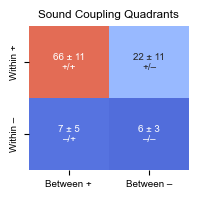

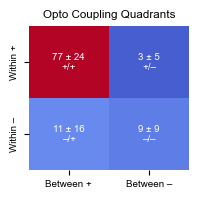

Chi-square test between sound and opto:
  χ² = 25.60, p = 1.156e-05, dof = 3
  Contingency Table:
       +/+  +/–  –/+  –/–
sound  466  178   38   35
opto    88    4   10    7
Permutation test p-value: 0.044, observed stat: 0.373


In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

def plot_quadrant_heatmap_across_datasets(
    combined_df,
    groups=('sound', 'opto'),
    dataset_col='dataset',
    group_col='group',
    save_dir=None,
    figsize=(3, 3),
    decimal_places = 0,
    vmax = 100
):
    mpl.rcParams['pdf.fonttype'] = 42
    plt.rcParams.update({'font.size': 7, 'font.family': 'arial'})

    quadrant_labels = np.array([["+/+", "+/–"], ["–/+", "–/–"]])
    quadrant_names = ['+/+', '+/–', '–/+', '–/–']
    
    # Store per-group stats
    all_group_stats = {}

    for group in groups:
        fractions = []
        raw_counts = []

        for dataset in combined_df[dataset_col].unique():
            subset = combined_df[
                (combined_df[group_col] == group) & (combined_df[dataset_col] == dataset)
            ]
            sign_within = np.sign(subset['coupling_within'].values)
            sign_between = np.sign(subset['coupling_between'].values)

            quadrant_counts = np.zeros((2, 2), dtype=int)
            for s_w, s_b in zip(sign_within, sign_between):
                row = 0 if s_w > 0 else 1
                col = 0 if s_b > 0 else 1
                quadrant_counts[row, col] += 1

            # Normalize to get fractions
            total = quadrant_counts.sum()
            if total == 0:
                continue
            fractions.append(quadrant_counts.flatten() / total)
            raw_counts.append(quadrant_counts.flatten())

        fractions = np.array(fractions) *100  # Convert to percentages
        mean_frac = np.nanmean(fractions, axis=0)
        std_frac = np.nanstd(fractions, axis=0)

        all_group_stats[group] = {
            'mean': mean_frac,
            'std': std_frac,
            'raw_counts': np.array(raw_counts)
        }

        # Plot heatmap of mean fractions
        mean_frac_matrix = mean_frac.reshape(2, 2)
        label_matrix = np.array([[f"{mean_frac_matrix[i,j]:.{decimal_places}f} ± {std_frac.reshape(2,2)[i,j]:.{decimal_places}f}\n{quadrant_labels[i,j]}"
                                  for j in range(2)] for i in range(2)])

        plt.figure(figsize=figsize)
        sns.heatmap(mean_frac_matrix, annot=label_matrix, fmt='', cmap='coolwarm', cbar=False,
                    xticklabels=["Between +", "Between –"], yticklabels=["Within +", "Within –"],vmin=0, vmax=vmax)
        plt.title(f'{group.capitalize()} Coupling Quadrants') #\n(Mean ± SD)
        plt.tight_layout()

        if save_dir:
            plt.savefig(f"{save_dir}/{group}_quadrant_heatmap.pdf", dpi=300)
        plt.show()

    # Perform chi-square test between groups (on total counts)
    if len(groups) >= 2:
        group1, group2 = groups[:2]
        total_counts_1 = np.sum(all_group_stats[group1]['raw_counts'], axis=0)
        total_counts_2 = np.sum(all_group_stats[group2]['raw_counts'], axis=0)

        contingency_table = np.stack([total_counts_1, total_counts_2], axis=0)
        chi2, p_val, dof, expected = chi2_contingency(contingency_table)

        print(f"Chi-square test between {group1} and {group2}:")
        print(f"  χ² = {chi2:.2f}, p = {p_val:.4g}, dof = {dof}")
        print("  Contingency Table:")
        print(pd.DataFrame(contingency_table, index=[group1, group2], columns=quadrant_names))

        # Optionally save
        if save_dir:
            pd.DataFrame(contingency_table, index=[group1, group2], columns=quadrant_names).to_csv(
                f"{save_dir}/quadrant_chi2_contingency.csv"
            )
            with open(f"{save_dir}/quadrant_chi2_result.txt", "w") as f:
                f.write(f"Chi-square test between {group1} and {group2}:\n")
                f.write(f"χ² = {chi2:.2f}, p = {p_val:.4g}, dof = {dof}\n")
                f.write("Contingency Table:\n")
                f.write(pd.DataFrame(contingency_table, index=[group1, group2], columns=quadrant_names).to_string())

    return all_group_stats


import numpy as np
import pandas as pd
import os

def permutation_test_quadrants(
    counts_group1: np.ndarray,
    counts_group2: np.ndarray,
    group1_name='sound',
    group2_name='opto',
    n_permutations=10000,
    seed=None,
    save_path=None
):
    """
    Performs a permutation test comparing quadrant fractions between two groups.

    Parameters:
        counts_group1 (np.ndarray): shape (n_datasets_1, 4), raw counts for group 1
        counts_group2 (np.ndarray): shape (n_datasets_2, 4), raw counts for group 2
        group1_name (str): Label for group 1
        group2_name (str): Label for group 2
        n_permutations (int): Number of permutations
        seed (int): Random seed for reproducibility
        save_path (str): Optional path to save permutation test and summary stats

    Returns:
        p_value (float): Permutation test p-value
        observed_stat (float): L1 norm of difference in means
        permuted_stats (np.ndarray): Distribution of permuted test statistics
    """
    if seed is not None:
        np.random.seed(seed)

    # Normalize to get fractions per dataset
    def normalize_counts(counts):
        return np.array([row / np.sum(row) if np.sum(row) > 0 else np.zeros_like(row) for row in counts])

    norm1 = normalize_counts(counts_group1)
    norm2 = normalize_counts(counts_group2)

    # Compute observed difference (L1 norm between group means)
    mean1 = np.mean(norm1, axis=0)
    mean2 = np.mean(norm2, axis=0)
    observed_stat = np.sum(np.abs(mean1 - mean2))

    # Stack data and generate labels
    all_data = np.vstack([norm1, norm2])
    group_labels = np.array([0] * len(norm1) + [1] * len(norm2))

    # Permutation loop
    permuted_stats = []
    for _ in range(n_permutations):
        shuffled = np.random.permutation(group_labels)
        grp_a = all_data[shuffled == 0]
        grp_b = all_data[shuffled == 1]
        stat = np.sum(np.abs(np.mean(grp_a, axis=0) - np.mean(grp_b, axis=0)))
        permuted_stats.append(stat)

    permuted_stats = np.array(permuted_stats)
    p_value = np.mean(permuted_stats >= observed_stat)

    # Save summary + CSVs
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)

        # Save mean/std summary
        summary_df = pd.DataFrame({
            'Quadrant': ['+/+', '+/–', '–/+', '–/–'],
            f'{group1_name}_mean': mean1,
            f'{group1_name}_std': np.std(norm1, axis=0),
            f'{group2_name}_mean': mean2,
            f'{group2_name}_std': np.std(norm2, axis=0),
        })
        summary_path = save_path.replace('.csv', '_summary_stats.csv')
        summary_df.to_csv(summary_path, index=False)

        # Save permutation result
        perm_df = pd.DataFrame({
            'observed_stat': [observed_stat],
            'p_value': [p_value]
        })
        perm_df.to_csv(save_path, index=False)

        print(f"Saved permutation test to: {save_path}")
        print(f"Saved summary stats to: {summary_path}")

    return p_value, observed_stat, permuted_stats


stats = plot_quadrant_heatmap_across_datasets(
    combined_df=coupling_df,
    groups=['sound', 'opto'],
    save_dir=None,#'W:/Connie/results/Bassi2025/glm_coupling/heatmaps'
    figsize=(2,2),
    decimal_places=0,
    vmax = 77
)

p_value, observed_stat, permuted_stats = permutation_test_quadrants(stats['sound']['raw_counts'], stats['opto']['raw_counts'], n_permutations=1000, seed=42) #stats['sound']['mean'].reshape(2,2)
print(f"Permutation test p-value: {p_value:.4g}, observed stat: {observed_stat:.3f}")